In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"taniyaaaaaaaaaa","key":"4f1b4935ef45932500d06b450f6671e5"}'}

In [2]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Kaggle key configured.")

Kaggle key configured.


In [4]:
!pip install -q kaggle
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [05:20<00:00, 17.4MB/s]



In [17]:
import os, pandas as pd

# Finding the images folder
for root, dirs, files in os.walk('/content/ham10000'):
    print(root, '->', len(files), 'files')
    if len(list(os.walk('/content/ham10000'))) > 10:
        break

/content/ham10000 -> 5 files
/content/ham10000/ham10000_images_part_2 -> 5015 files
/content/ham10000/HAM10000_images_part_1 -> 5000 files
/content/ham10000/ham10000_images_part_1 -> 5000 files
/content/ham10000/HAM10000_images_part_2 -> 5015 files


In [18]:
img_dir  = '/content/ham10000'
csv_path = '/content/ham10000/HAM10000_metadata.csv'

imgs = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
print(f"Images found : {len(imgs)}")

df = pd.read_csv(csv_path)
print(f"CSV rows     : {len(df)}")
print(df['dx'].value_counts())

Images found : 0
CSV rows     : 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [19]:
import os

for root, dirs, files in os.walk('/content/ham10000'):
    jpgs = [f for f in files if f.endswith('.jpg')]
    if jpgs:
        print(f"Found {len(jpgs)} images in: {root}")

Found 5015 images in: /content/ham10000/ham10000_images_part_2
Found 5000 images in: /content/ham10000/HAM10000_images_part_1
Found 5000 images in: /content/ham10000/ham10000_images_part_1
Found 5015 images in: /content/ham10000/HAM10000_images_part_2


In [21]:
import os, pandas as pd

img_dirs = [
    '/content/ham10000/HAM10000_images_part_1',
    '/content/ham10000/HAM10000_images_part_2'
]
csv_path = '/content/ham10000/HAM10000_metadata.csv'

# Counting total images
total = sum(len([f for f in os.listdir(d) if f.endswith('.jpg')]) for d in img_dirs)
print(f"Total images: {total}")

df = pd.read_csv(csv_path)
print(f"CSV rows    : {len(df)}")
print("\nClass distribution:")
print(df['dx'].value_counts())

Total images: 10015
CSV rows    : 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [22]:
# Mapping each image_id to its full file path
image_path_map = {}
for d in img_dirs:
    for fname in os.listdir(d):
        if fname.endswith('.jpg'):
            img_id = fname.replace('.jpg', '')
            image_path_map[img_id] = os.path.join(d, fname)

print(f"Images mapped: {len(image_path_map)}")

# Quick sanity check
sample_id = df['image_id'].iloc[0]
print(f"Sample path : {image_path_map[sample_id]}")

Images mapped: 10015
Sample path : /content/ham10000/HAM10000_images_part_1/ISIC_0027419.jpg


In [23]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split

In [24]:
class HAMDataset(Dataset):
    label_map = {'mel':0, 'nv':1, 'bcc':2, 'akiec':3, 'bkl':4, 'df':5, 'vasc':6}

    def __init__(self, df, image_path_map, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_path_map = image_path_map
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.image_path_map[row['image_id']]).convert('RGB')
        label = self.label_map[row['dx']]
        if self.transform:
            img = self.transform(img)
        return img, label

In [25]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [26]:
train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df['dx'], random_state=42
)
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

train_dataset = HAMDataset(train_df, image_path_map, transform=train_transform)
val_dataset   = HAMDataset(val_df,   image_path_map, transform=val_transform)

# Weighted sampler to handle class imbalance
class_counts = train_df['dx'].value_counts()
label_map = HAMDataset.label_map
weights = train_df['dx'].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(torch.DoubleTensor(weights), len(weights))

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,   num_workers=2)

print("DataLoaders ready.")

Train: 8012 | Val: 2003
DataLoaders ready.


In [27]:
imgs, labels = next(iter(train_loader))
print(f"Batch shape : {imgs.shape}")
print(f"Labels      : {labels}")

Batch shape : torch.Size([32, 3, 224, 224])
Labels      : tensor([0, 3, 6, 4, 3, 1, 6, 3, 3, 5, 4, 0, 5, 6, 1, 1, 5, 3, 4, 2, 0, 2, 0, 6,
        0, 5, 4, 4, 5, 6, 2, 4])


In [28]:
!pip install -q timm

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [29]:
import torch.nn as nn
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

def build_model(num_classes=7):
    model = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)

    # Freezing all backbone layers
    for param in model.parameters():
        param.requires_grad = False

    # Replacing classifier head for 7 classes
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model()
model = model.to(device)
print("Model ready.")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 103MB/s]


Model ready.
Trainable params: 10,759


In [30]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import numpy as np

# Weighted loss to handle class imbalance
class_counts_arr = np.array([1113, 6705, 1099, 327, 514, 115, 142], dtype=np.float32)
class_weights = 1.0 / class_counts_arr
class_weights = class_weights / class_weights.sum()
class_weights = torch.FloatTensor(class_weights).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only train the classifier head for now
optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=10)

print("Loss, optimizer, scheduler ready.")

Loss, optimizer, scheduler ready.


In [31]:
model.eval()
with torch.no_grad():
    imgs, labels = next(iter(val_loader))
    imgs = imgs.to(device)
    outputs = model(imgs)
    print(f"Input shape : {imgs.shape}")
    print(f"Output shape: {outputs.shape}")
    print(f"Sample preds: {outputs.argmax(1)[:8]}")

Input shape : torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 7])
Sample preds: tensor([0, 0, 6, 4, 4, 0, 0, 0], device='cuda:0')


In [32]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return 100. * correct / total

In [33]:
import os

save_dir = '/content/drive/MyDrive/HAM10000/checkpoints'
os.makedirs(save_dir, exist_ok=True)

def train(model, train_loader, val_loader, epochs=10):
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        scheduler.step()

        train_acc = 100. * correct / total
        val_acc   = evaluate(model, val_loader, device)

        print(f"Epoch [{epoch+1:02d}/{epochs}] "
              f"Loss: {running_loss/len(train_loader):.3f} | "
              f"Train acc: {train_acc:.1f}% | "
              f"Val acc: {val_acc:.1f}%")

        # Save best model to Drive
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(),
                       f'{save_dir}/best_model.pth')
            print(f"  --> Saved best model (val acc: {val_acc:.1f}%)")

    print(f"\nTraining complete. Best val acc: {best_val_acc:.1f}%")

In [35]:
train(model, train_loader, val_loader, epochs=10)

Epoch [01/10] Loss: 1.050 | Train acc: 34.1% | Val acc: 10.6%
  --> Saved best model (val acc: 10.6%)
Epoch [02/10] Loss: 0.808 | Train acc: 43.4% | Val acc: 16.4%
  --> Saved best model (val acc: 16.4%)
Epoch [03/10] Loss: 0.736 | Train acc: 47.4% | Val acc: 25.3%
  --> Saved best model (val acc: 25.3%)
Epoch [04/10] Loss: 0.712 | Train acc: 47.9% | Val acc: 28.5%
  --> Saved best model (val acc: 28.5%)
Epoch [05/10] Loss: 0.701 | Train acc: 50.2% | Val acc: 32.3%
  --> Saved best model (val acc: 32.3%)
Epoch [06/10] Loss: 0.661 | Train acc: 51.2% | Val acc: 29.9%
Epoch [07/10] Loss: 0.669 | Train acc: 52.1% | Val acc: 29.7%
Epoch [08/10] Loss: 0.678 | Train acc: 50.9% | Val acc: 30.8%
Epoch [09/10] Loss: 0.677 | Train acc: 51.4% | Val acc: 33.6%
  --> Saved best model (val acc: 33.6%)
Epoch [10/10] Loss: 0.656 | Train acc: 52.9% | Val acc: 32.1%

Training complete. Best val acc: 33.6%


In [37]:
# Unfreezing all layers
for param in model.parameters():
    param.requires_grad = True

# Lowering learning rate for fine-tuning
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

print("Backbone unfrozen. Starting fine-tuning...")
train(model, train_loader, val_loader, epochs=10)

Backbone unfrozen. Starting fine-tuning...
Epoch [01/10] Loss: 0.097 | Train acc: 86.0% | Val acc: 62.4%
  --> Saved best model (val acc: 62.4%)
Epoch [02/10] Loss: 0.085 | Train acc: 86.9% | Val acc: 61.2%
Epoch [03/10] Loss: 0.070 | Train acc: 88.8% | Val acc: 66.1%
  --> Saved best model (val acc: 66.1%)
Epoch [04/10] Loss: 0.064 | Train acc: 89.3% | Val acc: 69.2%
  --> Saved best model (val acc: 69.2%)
Epoch [05/10] Loss: 0.054 | Train acc: 90.5% | Val acc: 68.8%
Epoch [06/10] Loss: 0.047 | Train acc: 90.1% | Val acc: 68.5%
Epoch [07/10] Loss: 0.039 | Train acc: 91.7% | Val acc: 69.6%
  --> Saved best model (val acc: 69.6%)
Epoch [08/10] Loss: 0.035 | Train acc: 92.2% | Val acc: 69.2%
Epoch [09/10] Loss: 0.038 | Train acc: 92.4% | Val acc: 71.4%
  --> Saved best model (val acc: 71.4%)
Epoch [10/10] Loss: 0.033 | Train acc: 92.5% | Val acc: 71.7%
  --> Saved best model (val acc: 71.7%)

Training complete. Best val acc: 71.7%


In [38]:
model.load_state_dict(torch.load('/content/drive/MyDrive/HAM10000/checkpoints/best_model.pth'))
model.eval()
print("Best model loaded.")

Best model loaded.


In [39]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['mel', 'nv', 'bcc', 'akiec', 'bkl', 'df', 'vasc']

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

         mel       0.33      0.88      0.48       223
          nv       0.99      0.65      0.79      1341
         bcc       0.79      0.89      0.84       103
       akiec       0.68      0.85      0.75        65
         bkl       0.65      0.78      0.71       220
          df       0.88      0.96      0.92        23
        vasc       0.57      0.93      0.70        28

    accuracy                           0.72      2003
   macro avg       0.70      0.85      0.74      2003
weighted avg       0.85      0.72      0.75      2003



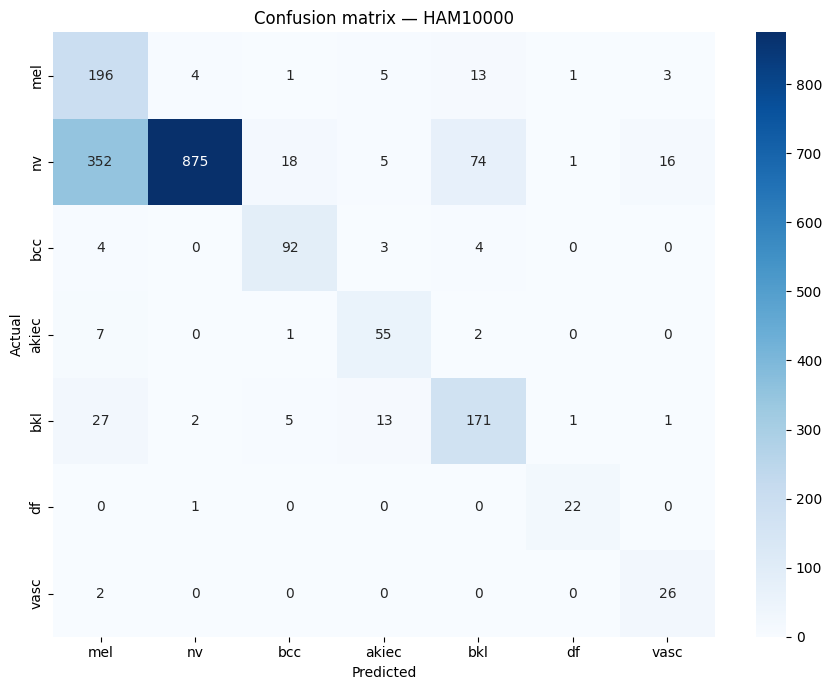

In [40]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix — HAM10000')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAM10000/confusion_matrix.png')
plt.show()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


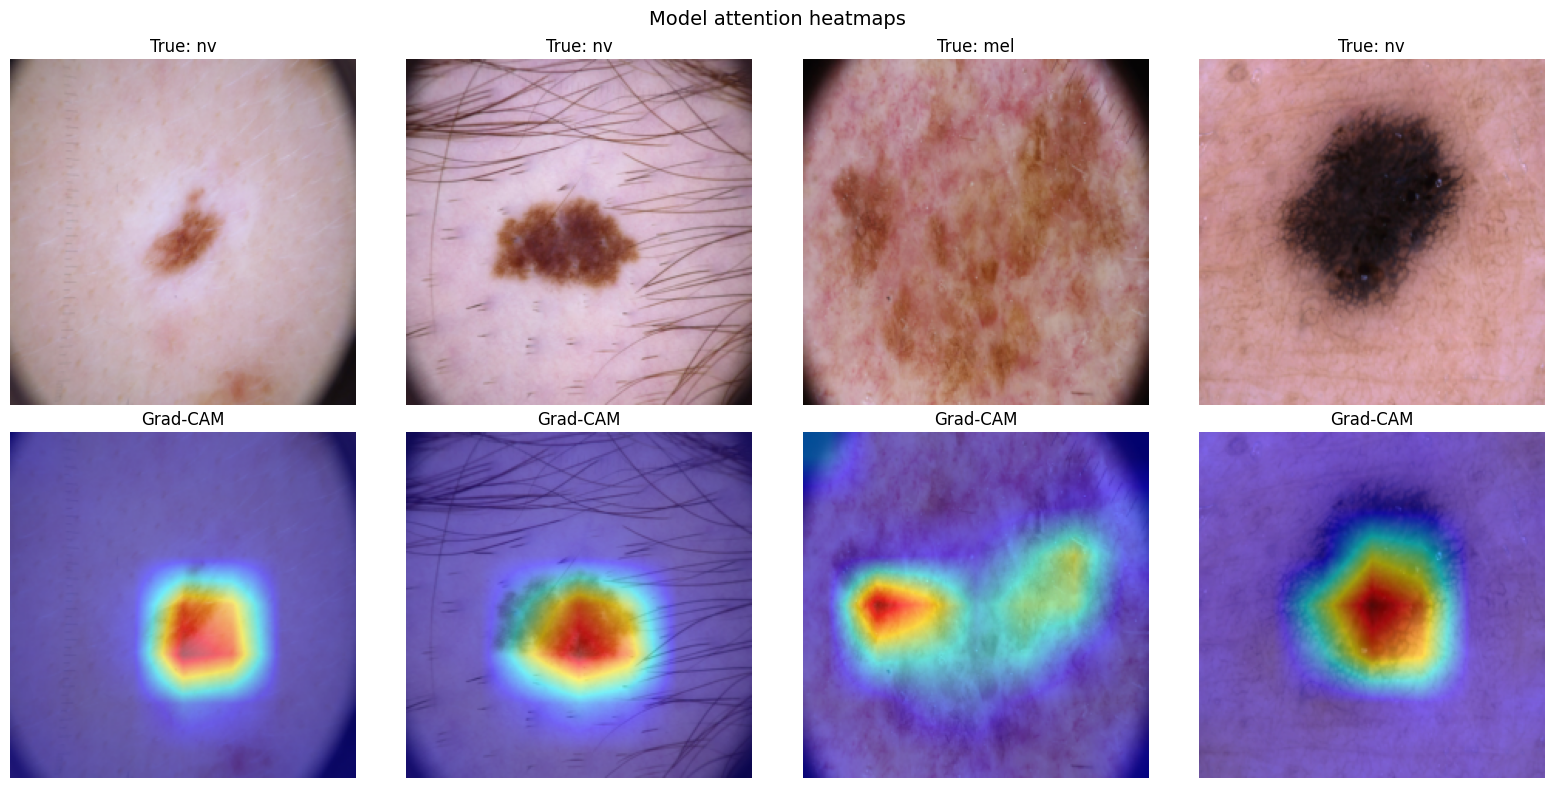

In [41]:
!pip install -q grad-cam

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

target_layer = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layer)

# Grab one batch from val
imgs, labels = next(iter(val_loader))
imgs = imgs.to(device)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    input_tensor = imgs[i].unsqueeze(0)
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Denormalize image for display
    raw = imgs[i].cpu().numpy().transpose(1, 2, 0)
    raw = raw * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    raw = np.clip(raw, 0, 1).astype(np.float32)

    visualization = show_cam_on_image(raw, grayscale_cam, use_rgb=True)

    axes[0][i].imshow(raw)
    axes[0][i].set_title(f"True: {class_names[labels[i]]}")
    axes[0][i].axis('off')

    axes[1][i].imshow(visualization)
    axes[1][i].set_title("Grad-CAM")
    axes[1][i].axis('off')

plt.suptitle("Model attention heatmaps", fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/HAM10000/gradcam.png')
plt.show()